In [1]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

import torch
import torch.optim as optim
import torchvision

from torchvision import transforms, models, datasets

import imageio.v2 as imageio
import time
# import warnings
# warnings.filterwarnings("ignore")
import random
import sys
import copy
import json
from PIL import Image


In [2]:
data_dir = "/mnt/d/Data/CS/workspace/project/4-4 图像识别模型训练策略/flower_data"
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")
import pathlib
pathlib.Path(data_dir).exists()

True

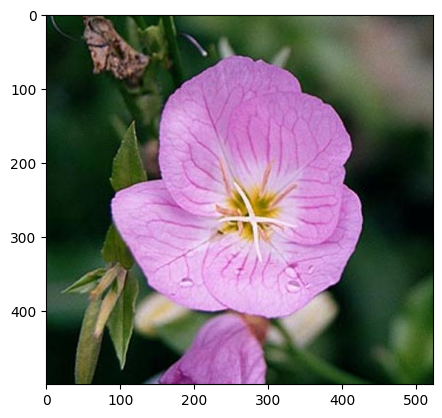

In [7]:
images = pathlib.Path(train_dir+"/1").glob("*.jpg")
data = imageio.imread(str(next(images)))
plt.imshow(data)

(500, 523, 3)
torch.Size([1, 3, 500, 523])
torch.Size([1, 3, 96, 96])


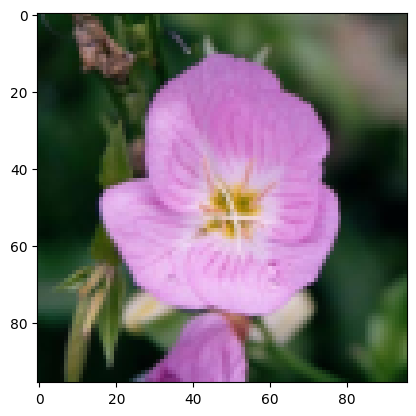

In [10]:
print(data.shape)
tensor_data = torch.from_numpy(data).unsqueeze(0).permute(0, 3, 1, 2)
print(tensor_data.shape)
resize_func = transforms.Resize([96, 96]) # 缩减图像
new_data = resize_func(tensor_data)
print(new_data.shape)
plt.imshow(new_data[0].permute(1, 2, 0).numpy())


## 预处理

In [12]:
data_transforms = {
    "train":
        transforms.Compose([
        transforms.Resize([96, 96]), # 裁剪图像到相同大小
        transforms.CenterCrop(64),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        # 亮度、对比度、饱和度、色调随机变化
        transforms.ColorJitter(brightness=0.2, contrast=1, saturation=0.1, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.2022, 0.224, 0.225])
        ]),
    "valid":
        transforms.Compose([
        transforms.Resize([64, 64]),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.2022, 0.224, 0.225])
        ])
}

torch.Size([3, 64, 64])


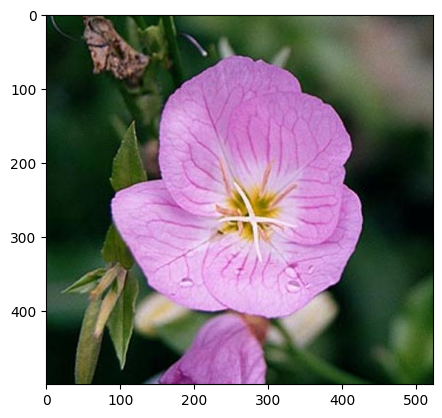

In [22]:
images = pathlib.Path(train_dir+"/1").glob("*.jpg")
image = Image.open(next(images))
plt.imshow(image)
new_data = data_transforms["train"](image)
print(new_data.shape)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1270924..2.64].


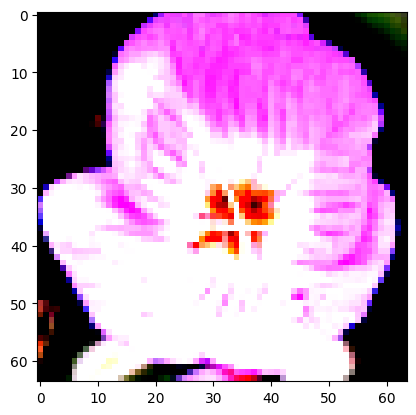

In [23]:
plt.imshow(new_data.permute(1, 2, 0).numpy())

In [24]:
batch_size = 128

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ["train", "valid"]}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True) for x in ["train", "valid"]}
dataset_sizes = {x: len(image_datasets[x]) for x in ["train", "valid"]}
class_names = image_datasets["train"].classes
print(class_names)

['1', '10', '100', '101', '102', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


In [25]:
image_datasets

{'train': Dataset ImageFolder
     Number of datapoints: 6552
     Root location: /mnt/d/Data/CS/workspace/project/4-4 图像识别模型训练策略/flower_data/train
     StandardTransform
 Transform: Compose(
                Resize(size=[96, 96], interpolation=bilinear, max_size=None, antialias=True)
                CenterCrop(size=(64, 64))
                RandomHorizontalFlip(p=0.5)
                RandomVerticalFlip(p=0.5)
                ColorJitter(brightness=(0.8, 1.2), contrast=(0.0, 2.0), saturation=(0.9, 1.1), hue=(-0.1, 0.1))
                RandomGrayscale(p=0.1)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.2022, 0.224, 0.225])
            ),
 'valid': Dataset ImageFolder
     Number of datapoints: 818
     Root location: /mnt/d/Data/CS/workspace/project/4-4 图像识别模型训练策略/flower_data/valid
     StandardTransform
 Transform: Compose(
                Resize(size=[64, 64], interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
 

In [27]:
with open('/mnt/d/Data/CS/workspace/project/4-4 图像识别模型训练策略/cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f)

In [28]:
cat_to_name

{'21': 'fire lily',
 '3': 'canterbury bells',
 '45': 'bolero deep blue',
 '1': 'pink primrose',
 '34': 'mexican aster',
 '27': 'prince of wales feathers',
 '7': 'moon orchid',
 '16': 'globe-flower',
 '25': 'grape hyacinth',
 '26': 'corn poppy',
 '79': 'toad lily',
 '39': 'siam tulip',
 '24': 'red ginger',
 '67': 'spring crocus',
 '35': 'alpine sea holly',
 '32': 'garden phlox',
 '10': 'globe thistle',
 '6': 'tiger lily',
 '93': 'ball moss',
 '33': 'love in the mist',
 '9': 'monkshood',
 '102': 'blackberry lily',
 '14': 'spear thistle',
 '19': 'balloon flower',
 '100': 'blanket flower',
 '13': 'king protea',
 '49': 'oxeye daisy',
 '15': 'yellow iris',
 '61': 'cautleya spicata',
 '31': 'carnation',
 '64': 'silverbush',
 '68': 'bearded iris',
 '63': 'black-eyed susan',
 '69': 'windflower',
 '62': 'japanese anemone',
 '20': 'giant white arum lily',
 '38': 'great masterwort',
 '4': 'sweet pea',
 '86': 'tree mallow',
 '101': 'trumpet creeper',
 '42': 'daffodil',
 '22': 'pincushion flower',
 

In [35]:
model_name = 'resnet'  # 可选的比较多 ['resnet', 'alexnet', 'vgg', 'squeezenet', 'densenet', 'inception']
#是否用人家训练好的特征来做
feature_extract = True # 都用人家特征，咱先不更新

In [36]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


cuda:0


In [37]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [38]:
model_ft = models.resnet152()#18层的能快点，条件好点的也可以选152
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

修改输出层

In [ ]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True) -> tuple[models.ResNet, int]:
    model_ft = models.resnet152(pretrained=use_pretrained)
    set_parameter_requires_grad(model_ft, feature_extract)
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = torch.nn.Linear(num_ftrs, num_classes)
    input_size = 96
    return model_ft, input_size

设置哪些层需要训练

In [ ]:
model_ft, input_size = initialize_model(model_name, 102, feature_extract, use_pretrained=True)

#GPU还是CPU计算
model_ft = model_ft.to(device)

# 模型保存，名字自己起
filename='best.pt'

# 是否训练所有层
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t",name)

/home/moyin/llm-python/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/moyin/llm-python/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /home/moyin/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:12<00:00, 19.2MB/s] 


Params to learn:
	 fc.weight
	 fc.bias


In [ ]:
# 优化器设置
import torch.nn as nn
optimizer_ft = optim.Adam(params_to_update, lr=1e-2)#要训练啥参数，你来定
# 学习率每7个epoch衰减成原来的1/10
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=20, gamma=0.1)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train_model(model: models.ResNet, dataloaders, criterion, optimizer, num_epochs=25,filename='best.pt'):
    #咱们要算时间的
    since = time.time()
    #也要记录最好的那一次
    best_acc = 0
    #模型也得放到你的CPU或者GPU
    model.to(device)
    #训练过程中打印一堆损失和指标
    val_acc_history = []
    train_acc_history = []
    train_losses = []
    valid_losses = []
    #学习率
    LRs = [optimizer.param_groups[0]['lr']]
    #最好的那次模型，后续会变的，先初始化
    best_model_wts = copy.deepcopy(model.state_dict())
    #一个个epoch来遍历
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # 训练和验证
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # 训练
            else:
                model.eval()   # 验证

            running_loss = 0.0
            running_corrects = 0

            # 把数据都取个遍
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)#放到你的CPU或GPU
                labels = labels.to(device)

                # 清零
                optimizer.zero_grad()
                # 只有训练的时候计算和更新梯度
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                # 训练阶段更新权重
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # 计算损失
                running_loss += loss.item() * inputs.size(0)#0表示batch那个维度
                running_corrects += torch.sum(preds == labels.data)#预测结果最大的和真实值是否一致

            epoch_loss = running_loss / len(dataloaders[phase].dataset)#算平均
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            
            time_elapsed = time.time() - since#一个epoch我浪费了多少时间
            print('Time elapsed {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))
            

            # 得到最好那次的模型
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                state = {
                  'state_dict': model.state_dict(),#字典里key就是各层的名字，值就是训练好的权重
                  'best_acc': best_acc,
                  'optimizer' : optimizer.state_dict(),
                }
                torch.save(state, filename)
            if phase == 'valid':
                val_acc_history.append(epoch_acc)
                valid_losses.append(epoch_loss)
                #scheduler.step(epoch_loss)#学习率衰减
            if phase == 'train':
                train_acc_history.append(epoch_acc)
                train_losses.append(epoch_loss)
        
        print('Optimizer learning rate : {:.7f}'.format(optimizer.param_groups[0]['lr']))
        LRs.append(optimizer.param_groups[0]['lr'])
        print()
        scheduler.step()#学习率衰减

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # 训练完后用最好的一次当做模型最终的结果,等着一会测试
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_acc_history, valid_losses, train_losses, LRs 

In [ ]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs = train_model(model_ft,
             dataloaders, criterion, optimizer_ft, num_epochs=50)

Epoch 0/49
----------
Time elapsed 0m 47s
train Loss: 1.8348 Acc: 0.6407
Time elapsed 0m 52s
valid Loss: 3.5486 Acc: 0.4878
Optimizer learning rate : 0.0001000

Epoch 1/49
----------
Time elapsed 1m 38s
train Loss: 1.7662 Acc: 0.6403
Time elapsed 1m 44s
valid Loss: 3.5936 Acc: 0.4914
Optimizer learning rate : 0.0001000

Epoch 2/49
----------
Time elapsed 2m 31s
train Loss: 1.7236 Acc: 0.6421
Time elapsed 2m 36s
valid Loss: 3.5567 Acc: 0.4914
Optimizer learning rate : 0.0001000

Epoch 3/49
----------
Time elapsed 3m 23s
train Loss: 1.7649 Acc: 0.6404
Time elapsed 3m 28s
valid Loss: 3.4974 Acc: 0.4976
Optimizer learning rate : 0.0001000

Epoch 4/49
----------
Time elapsed 4m 16s
train Loss: 1.7813 Acc: 0.6374
Time elapsed 4m 22s
valid Loss: 3.4715 Acc: 0.5037
Optimizer learning rate : 0.0001000

Epoch 5/49
----------
Time elapsed 5m 10s
train Loss: 1.7145 Acc: 0.6487
Time elapsed 5m 15s
valid Loss: 3.4923 Acc: 0.4878
Optimizer learning rate : 0.0001000

Epoch 6/49
----------
Time elapsed

In [62]:
for param in model_ft.parameters():
    param.requires_grad = True

# 再继续训练所有的参数，学习率调小一点
optimizer = optim.Adam(model_ft.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 损失函数
criterion = nn.CrossEntropyLoss()

# 加载之前训练好的权重参数
filename='best.pt'
checkpoint = torch.load(filename)
best_acc = checkpoint['best_acc']
res = model_ft.load_state_dict(checkpoint['state_dict'])
print(res)

<All keys matched successfully>


In [66]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs  = train_model(model_ft, 
                    dataloaders, criterion, optimizer, num_epochs=1, filename='train_all_best.pt')

Epoch 0/0
----------
Time elapsed 0m 53s
train Loss: 0.2669 Acc: 0.9264
Time elapsed 0m 59s
valid Loss: 2.1838 Acc: 0.5844
Optimizer learning rate : 0.0010000

Training complete in 1m 0s
Best val Acc: 0.584352


测试

In [45]:
model_ft, input_size = initialize_model(model_name, 102, feature_extract, use_pretrained=True)

# GPU模式
model_ft = model_ft.to(device)

# 保存文件的名字
filename='best.pt'

# 加载模型
checkpoint = torch.load(filename)
best_acc = checkpoint['best_acc']
model_ft.load_state_dict(checkpoint['state_dict'])

<All keys matched successfully>

In [48]:
# 得到一个batch的测试数据
dataiter = iter(dataloaders['valid'])
images, labels = dataiter._next_data()

model_ft.eval()

if device.type == 'cuda':
    output = model_ft(images.cuda())
else:
    output = model_ft(images)

In [49]:
output.shape

torch.Size([128, 102])

In [51]:
_, preds_tensor = torch.max(output, 1)

preds = np.squeeze(preds_tensor.numpy()) if not device.type == 'cuda' else np.squeeze(preds_tensor.cpu().numpy())
preds

array([ 52,  77,  57,  75,  53,  44,  97,  46,  23,  64,  73,  75,  13,
        85,  33,  65,  18,  89,  55,  99,  78,  23, 101,  88,  82,  70,
        19,  98,  64,  89,  76,  43,  56,  11,  66,  56,  33,  85,  38,
        97,  74,  85,  73,  90,  73,  48,  86,  89, 100,  43,  97,  72,
        53,   8,  89,  77,  81,  85,  37,  10,  11,  86,  54,  89, 101,
        68,   1,  77,  40,  48,  84,   1,  95,  46,  85,  12,   9,  77,
         5,  49,  18,  89,  43,  25,  17,   5,  96,  76,  49,  49,   6,
        23,  98,  64,  93,  71,  57,  82,  85,  89,  54,  77,  29,  23,
        76,  55,  31,  75,  49,  49,  82,  41,  13,  43,  36,  38,  38,
        97,  56,  56,  78,  43,  27,   2,  57,  89,  67,  10])

In [52]:
def im_convert(tensor):
    """ 展示数据"""
    
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)

    return image

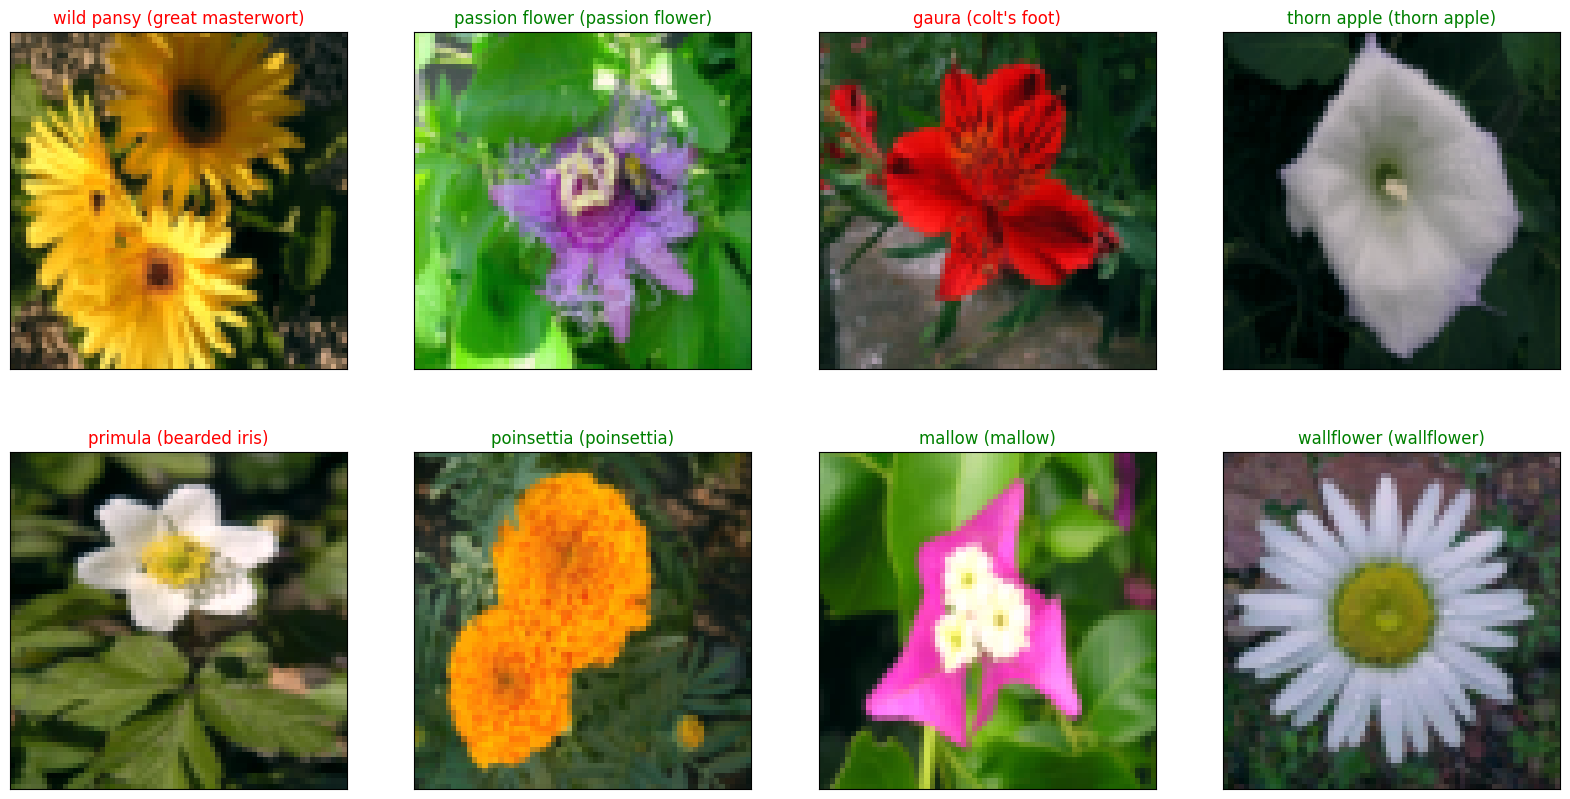

In [54]:
fig=plt.figure(figsize=(20, 10))
columns =4
rows = 2

for idx in range (columns*rows):
    ax = fig.add_subplot(rows, columns, idx+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))
    ax.set_title("{} ({})".format(cat_to_name[str(preds[idx])], cat_to_name[str(labels[idx].item())]),
                 color=("green" if cat_to_name[str(preds[idx])]==cat_to_name[str(labels[idx].item())] else "red"))
plt.show()